# Model XGBoost – Predicció de Generació Renovable
**TFG – Gestió de Ciutats Intel·ligents i Sostenibles**  
**Arnau Ropero Garcia | UAB | Curs 2025–26**

Aquest notebook implementa el model **XGBoost** per predir la generació solar i eòlica a Espanya.

- **Entrenament:** 2023–2024 (17.377 registres)
- **Validació:** Gener–Març 2025 (2.161 registres)
- **Test / Cas d'estudi:** Abril–Maig 2025 (1.462 registres, inclou apagada 28 abril)

**Diferències respecte a Prophet:**
- XGBoost és un model tabular: rep totes les features alhora, sense noció de seqüència temporal
- Usa les variables de lag (1h, 24h, 168h) com a features explícites
- Ajust d'hiperparàmetres per cerca en graella sobre el conjunt de validació

## 0. Instal·lació de dependències

In [4]:
# Executar només si no tens xgboost instal·lat
%pip install xgboost scikit-learn

Defaulting to user installation because normal site-packages is not writeable
   ---------------------------------------- 0.0/101.7 MB ? eta -:--:--
    --------------------------------------- 2.4/101.7 MB 38.5 MB/s eta 0:00:03
   ----- ---------------------------------- 13.6/101.7 MB 52.0 MB/s eta 0:00:02
   --------- ------------------------------ 23.9/101.7 MB 50.3 MB/s eta 0:00:02
   ------------- -------------------------- 34.6/101.7 MB 50.2 MB/s eta 0:00:02
   ---------------- ----------------------- 43.0/101.7 MB 49.4 MB/s eta 0:00:02
   ------------------- -------------------- 49.5/101.7 MB 45.3 MB/s eta 0:00:02
   ----------------------- ---------------- 59.0/101.7 MB 45.5 MB/s eta 0:00:01
   --------------------------- ------------ 69.2/101.7 MB 45.9 MB/s eta 0:00:01
   ------------------------------- -------- 80.2/101.7 MB 46.9 MB/s eta 0:00:01
   ---------------------------------- ----- 87.8/101.7 MB 45.6 MB/s eta 0:00:01
   ------------------------------------- -- 96.2/101


[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


## 1. Importacions

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import xgboost as xgb
from sklearn.metrics import mean_absolute_error, mean_squared_error
import warnings
warnings.filterwarnings('ignore')

np.random.seed(42)
plt.rcParams['figure.figsize'] = (14, 5)
plt.rcParams['font.size'] = 11

print(f'XGBoost versió: {xgb.__version__}')
print('Llibreries carregades correctament.')

XGBoost versió: 3.2.0
Llibreries carregades correctament.


## 2. Càrrega i inspecció del dataset

In [6]:
PATH = r'C:\Users\Arnau\Universitat\Grau de gestió de ciutats intel·ligents i sostenibles\4rt curs\TFG\dades\dataset_final_2023-2025.csv'

df = pd.read_csv(PATH, parse_dates=['timestamp_utc'], index_col='timestamp_utc')
df.index = pd.to_datetime(df.index, utc=True).tz_convert('Europe/Madrid')

print(f'Shape: {df.shape}')
print(f'Rang temporal: {df.index.min()} → {df.index.max()}')
print(f'\nColumnes: {list(df.columns)}')

Shape: (21000, 25)
Rang temporal: 2023-01-08 00:00:00+01:00 → 2025-05-31 23:00:00+02:00

Columnes: ['solar_MW', 'eolic_MW', 'shortwave_radiation_Wm2', 'direct_radiation_Wm2', 'diffuse_radiation_Wm2', 'cloud_cover_pct', 'wind_speed_100m_ms', 'wind_speed_10m_ms', 'wind_gusts_10m_ms', 'temperature_2m_C', 'precipitation_mm', 'hora', 'dia_setmana', 'mes', 'dia_any', 'any', 'is_cap_de_setmana', 'is_festiu', 'solar_MW_lag1h', 'eolic_MW_lag1h', 'solar_MW_lag24h', 'eolic_MW_lag24h', 'solar_MW_lag168h', 'eolic_MW_lag168h', 'split']


## 3. Divisió temporal (train / val / test)

In [7]:
train = df[df['split'] == 'train'].copy()
val   = df[df['split'] == 'validation'].copy()
test  = df[df['split'] == 'test'].copy()

print(f'Train: {train.index.min().date()} → {train.index.max().date()}  ({len(train):,} registres)')
print(f'Val:   {val.index.min().date()} → {val.index.max().date()}  ({len(val):,} registres)')
print(f'Test:  {test.index.min().date()} → {test.index.max().date()}  ({len(test):,} registres)')

Train: 2023-01-08 → 2025-01-01  (17,377 registres)
Val:   2025-01-01 → 2025-04-01  (2,161 registres)
Test:  2025-04-01 → 2025-05-31  (1,462 registres)


## 4. Definició de features

XGBoost usa totes les variables disponibles com a features:
- **Meteorològiques:** irradiació, vent, temperatura, nuvolositat, precipitació
- **Calendari:** hora, dia_setmana, mes, dia_any, cap_de_setmana, festiu
- **Lags de generació:** 1h, 24h, 168h (setmanal)

⚠️ Els lags de generació contenen valors de la variable target del passat,
no del futur → no hi ha data leakage. Per a l'hora h, `solar_MW_lag1h`
conté el valor de l'hora h-1, que ja és conegut.

In [8]:
FEATURES_SOLAR = [
    # Meteorologia solar
    'shortwave_radiation_Wm2',
    'direct_radiation_Wm2',
    'diffuse_radiation_Wm2',
    'cloud_cover_pct',
    'temperature_2m_C',
    # Calendari
    'hora',
    'dia_setmana',
    'mes',
    'dia_any',
    'is_cap_de_setmana',
    'is_festiu',
    # Lags solar
    'solar_MW_lag1h',
    'solar_MW_lag24h',
    'solar_MW_lag168h',
]

FEATURES_EOLIC = [
    # Meteorologia eòlica
    'wind_speed_100m_ms',
    'wind_speed_10m_ms',
    'wind_gusts_10m_ms',
    'temperature_2m_C',
    'precipitation_mm',
    # Calendari
    'hora',
    'dia_setmana',
    'mes',
    'dia_any',
    'is_cap_de_setmana',
    'is_festiu',
    # Lags eòlica
    'eolic_MW_lag1h',
    'eolic_MW_lag24h',
    'eolic_MW_lag168h',
]

TARGET_SOLAR = 'solar_MW'
TARGET_EOLIC = 'eolic_MW'

print(f'Features solar: {len(FEATURES_SOLAR)}')
print(f'Features eòlica: {len(FEATURES_EOLIC)}')

Features solar: 14
Features eòlica: 14


## 5. Funcions auxiliars

In [9]:
def calcular_metriques(y_true, y_pred, nom=''):
    """Calcula MAE, RMSE i MAPE (excloent zeros) i les retorna en un dict."""
    mae  = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mask = y_true > 0
    mape = np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100
    if nom:
        print(f'--- {nom} ---')
    print(f'  MAE : {mae:,.1f} MW')
    print(f'  RMSE: {rmse:,.1f} MW')
    print(f'  MAPE: {mape:.2f} %')
    return {'MAE': mae, 'RMSE': rmse, 'MAPE': mape}


def plot_prediccions(dates, y_true, y_pred, titol, y_label='MW',
                     highlight_start=None, highlight_end=None):
    fig, ax = plt.subplots(figsize=(14, 5))
    ax.plot(dates, y_true, label='Real', color='steelblue', linewidth=1)
    ax.plot(dates, y_pred, label='Predicció XGBoost', color='darkorange',
            linewidth=1, linestyle='--')
    if highlight_start and highlight_end:
        ax.axvspan(pd.Timestamp(highlight_start), pd.Timestamp(highlight_end),
                   alpha=0.15, color='orange', label='Apagada 28 abr')
    ax.set_title(titol, fontweight='bold')
    ax.set_ylabel(y_label)
    ax.set_xlabel('Data')
    ax.legend()
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%d-%b'))
    fig.autofmt_xdate()
    plt.tight_layout()
    plt.show()


print('Funcions auxiliars definides.')

Funcions auxiliars definides.


---
## 6. MODEL A: Solar PV
### 6.1 Preparació de dades

In [10]:
X_train_solar = train[FEATURES_SOLAR]
y_train_solar = train[TARGET_SOLAR]

X_val_solar   = val[FEATURES_SOLAR]
y_val_solar   = val[TARGET_SOLAR]

X_test_solar  = test[FEATURES_SOLAR]
y_test_solar  = test[TARGET_SOLAR]

print(f'X_train_solar: {X_train_solar.shape}')
print(f'X_val_solar:   {X_val_solar.shape}')
print(f'X_test_solar:  {X_test_solar.shape}')

X_train_solar: (17377, 14)
X_val_solar:   (2161, 14)
X_test_solar:  (1462, 14)


### 6.2 Entrenament amb early stopping

Usem el conjunt de validació per aturar l'entrenament quan l'error
deixa de millorar, evitant sobreajustament (overfitting).

In [14]:
xgb_solar = xgb.XGBRegressor(
    n_estimators       = 2000,   # màxim d'arbres; early stopping els tallarà
    learning_rate      = 0.05,
    max_depth          = 6,
    subsample          = 0.8,
    colsample_bytree   = 0.8,
    min_child_weight   = 5,
    reg_alpha          = 0.1,    # regularització L1
    reg_lambda         = 1.0,    # regularització L2
    early_stopping_rounds = 50,
    random_state       = 42,
    n_jobs             = -1,
    verbosity          = 0,
)

xgb_solar.fit(
    X_train_solar, y_train_solar,
    eval_set      = [(X_val_solar, y_val_solar)],
    verbose       = 100,   # mostra el progrés cada 100 arbres
)

print(f'\nArbres usats: {xgb_solar.best_iteration + 1}')

[0]	validation_0-rmse:5337.92399
[100]	validation_0-rmse:694.05598
[200]	validation_0-rmse:647.44285
[300]	validation_0-rmse:626.59540
[400]	validation_0-rmse:616.01043
[500]	validation_0-rmse:606.65305
[600]	validation_0-rmse:601.51088
[700]	validation_0-rmse:598.62293
[800]	validation_0-rmse:595.16601
[900]	validation_0-rmse:591.82736
[1000]	validation_0-rmse:590.13744
[1100]	validation_0-rmse:588.20015
[1164]	validation_0-rmse:588.11234

Arbres usats: 1115


### 6.3 Predicció i avaluació – Validació

--- SOLAR – Validació ---
  MAE : 311.0 MW
  RMSE: 587.7 MW
  MAPE: 28.28 %


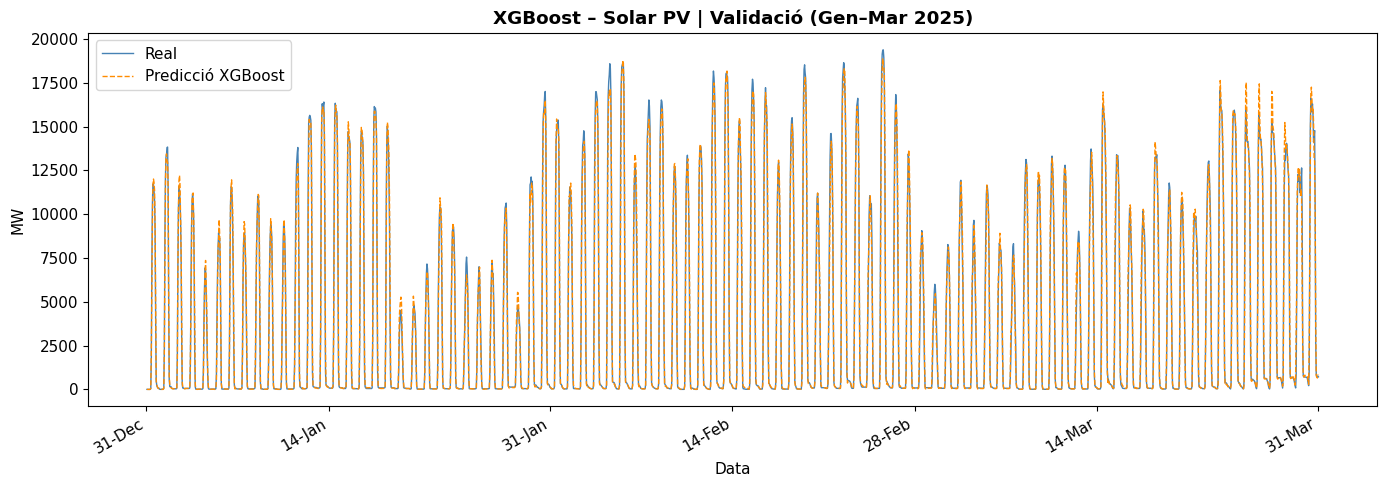

In [15]:
y_pred_val_solar = np.clip(xgb_solar.predict(X_val_solar), 0, None)
metriques_val_solar = calcular_metriques(
    y_val_solar.values, y_pred_val_solar, 'SOLAR – Validació'
)

plot_prediccions(
    dates  = val.index,
    y_true = y_val_solar.values,
    y_pred = y_pred_val_solar,
    titol  = 'XGBoost – Solar PV | Validació (Gen–Mar 2025)'
)

### 6.4 Predicció i avaluació – Test (amb apagada)

--- SOLAR – Test ---
  MAE : 414.6 MW
  RMSE: 729.5 MW
  MAPE: 20.04 %


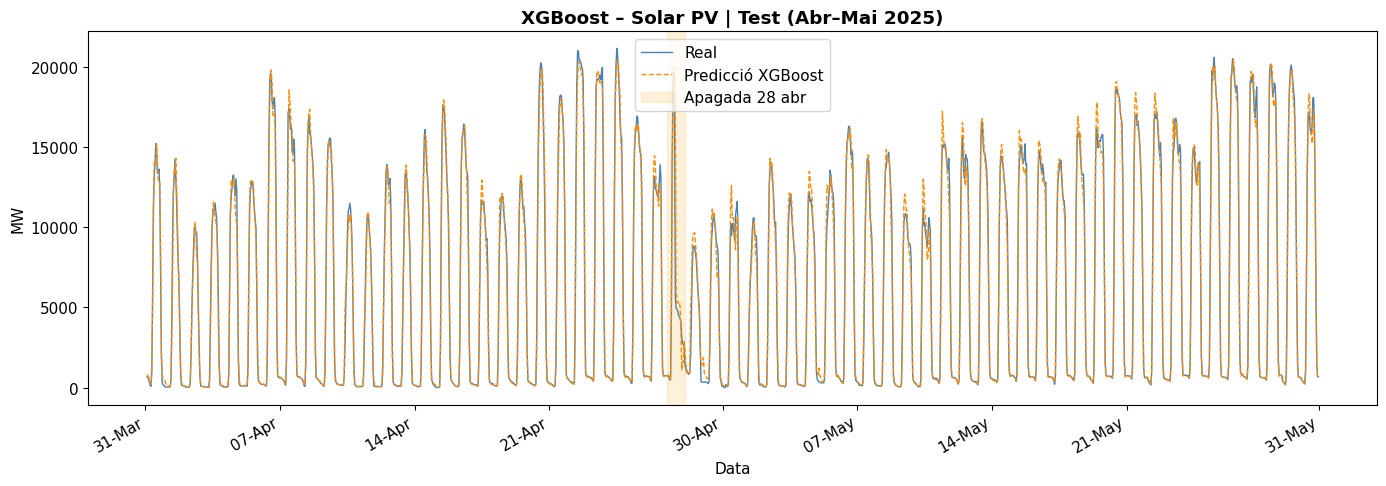

In [17]:
y_pred_test_solar = np.clip(xgb_solar.predict(X_test_solar), 0, None)
metriques_test_solar = calcular_metriques(
    y_test_solar.values, y_pred_test_solar, 'SOLAR – Test'
)

plot_prediccions(
    dates           = test.index,
    y_true          = y_test_solar.values,
    y_pred          = y_pred_test_solar,
    titol           = 'XGBoost – Solar PV | Test (Abr–Mai 2025)',
    highlight_start = '2025-04-28 00:00',
    highlight_end   = '2025-04-28 23:00'
)

### 6.5 Importància de features – Solar

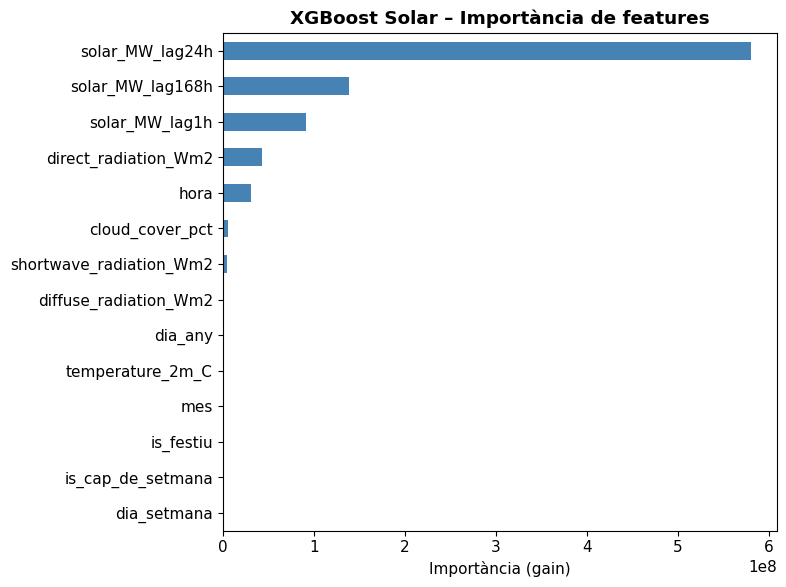

In [18]:
importances_solar = pd.Series(
    xgb_solar.get_booster().get_score(importance_type='gain'),
).reindex(FEATURES_SOLAR).fillna(0
).sort_values(ascending=True)
# 'gain': reducció mitjana de l'error aportada; més informatiu que 'weight'

fig, ax = plt.subplots(figsize=(8, 6))
importances_solar.plot(kind='barh', ax=ax, color='steelblue')
ax.set_title('XGBoost Solar – Importància de features', fontweight='bold')
ax.set_xlabel('Importància (gain)')
plt.tight_layout()
plt.savefig('xgboost_solar_feature_importance.pdf', bbox_inches='tight')
plt.show()

### 6.6 Anàlisi d'anomalies – Apagada 28 d'abril

Llindar anomalia solar: 1,615 MW
Hores anomàlies total: 64


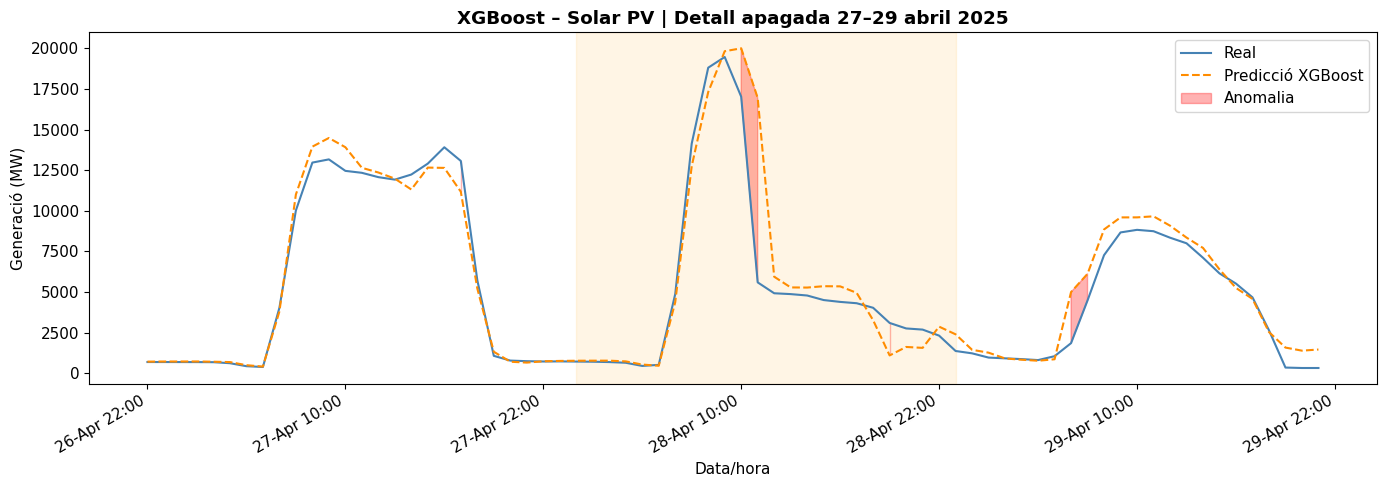

In [19]:
# Calcular residus al conjunt de test
residus_solar = pd.DataFrame({
    'ds':      test.index,
    'y_real':  y_test_solar.values,
    'y_pred':  y_pred_test_solar,
    'residu':  y_test_solar.values - y_pred_test_solar,
})

# Llindar d'anomalia: mean + 2*std dels residus absoluts
llindar_solar = residus_solar['residu'].abs().mean() + \
                2 * residus_solar['residu'].abs().std()
residus_solar['anomalia'] = residus_solar['residu'].abs() > llindar_solar

print(f'Llindar anomalia solar: {llindar_solar:,.0f} MW')
print(f'Hores anomàlies total: {residus_solar["anomalia"].sum()}')

# Zoom 27–29 abril
mask = (residus_solar['ds'] >= '2025-04-27') & \
       (residus_solar['ds'] <= '2025-04-29 23:00')
sub = residus_solar[mask]

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(sub['ds'], sub['y_real'], label='Real', color='steelblue', linewidth=1.5)
ax.plot(sub['ds'], sub['y_pred'], label='Predicció XGBoost', color='darkorange',
        linewidth=1.5, linestyle='--')
ax.fill_between(sub['ds'], sub['y_real'], sub['y_pred'],
                where=sub['anomalia'], alpha=0.3, color='red', label='Anomalia')
ax.axvspan(pd.Timestamp('2025-04-28 00:00'), pd.Timestamp('2025-04-28 23:00'),
           alpha=0.1, color='orange')
ax.set_title('XGBoost – Solar PV | Detall apagada 27–29 abril 2025', fontweight='bold')
ax.set_ylabel('Generació (MW)')
ax.set_xlabel('Data/hora')
ax.legend()
ax.xaxis.set_major_formatter(mdates.DateFormatter('%d-%b %H:%M'))
fig.autofmt_xdate()
plt.tight_layout()
plt.savefig('xgboost_solar_detall_apagada.pdf', bbox_inches='tight')
plt.show()

---
## 7. MODEL B: Eòlica
### 7.1 Preparació de dades

In [21]:
X_train_eolic = train[FEATURES_EOLIC]
y_train_eolic = train[TARGET_EOLIC]

X_val_eolic   = val[FEATURES_EOLIC]
y_val_eolic   = val[TARGET_EOLIC]

X_test_eolic  = test[FEATURES_EOLIC]
y_test_eolic  = test[TARGET_EOLIC]

print(f'X_train_eolic: {X_train_eolic.shape}')
print(f'X_val_eolic:   {X_val_eolic.shape}')
print(f'X_test_eolic:  {X_test_eolic.shape}')

X_train_eolic: (17377, 14)
X_val_eolic:   (2161, 14)
X_test_eolic:  (1462, 14)


### 7.2 Entrenament

In [23]:
xgb_eolic = xgb.XGBRegressor(
    n_estimators       = 1000,
    learning_rate      = 0.05,
    max_depth          = 6,
    subsample          = 0.8,
    colsample_bytree   = 0.8,
    min_child_weight   = 5,
    reg_alpha          = 0.1,
    reg_lambda         = 1.0,
    early_stopping_rounds = 50,
    random_state       = 42,
    n_jobs             = -1,
    verbosity          = 0,
)

xgb_eolic.fit(
    X_train_eolic, y_train_eolic,
    eval_set = [(X_val_eolic, y_val_eolic)],
    verbose  = 100,
)

print(f'\nArbres usats: {xgb_eolic.best_iteration + 1}')

[0]	validation_0-rmse:4048.91836
[100]	validation_0-rmse:542.55957
[200]	validation_0-rmse:530.66491
[241]	validation_0-rmse:531.20248

Arbres usats: 192


### 7.3 Predicció i avaluació – Validació

--- EÒLICA – Validació ---
  MAE : 387.1 MW
  RMSE: 530.0 MW
  MAPE: 5.95 %


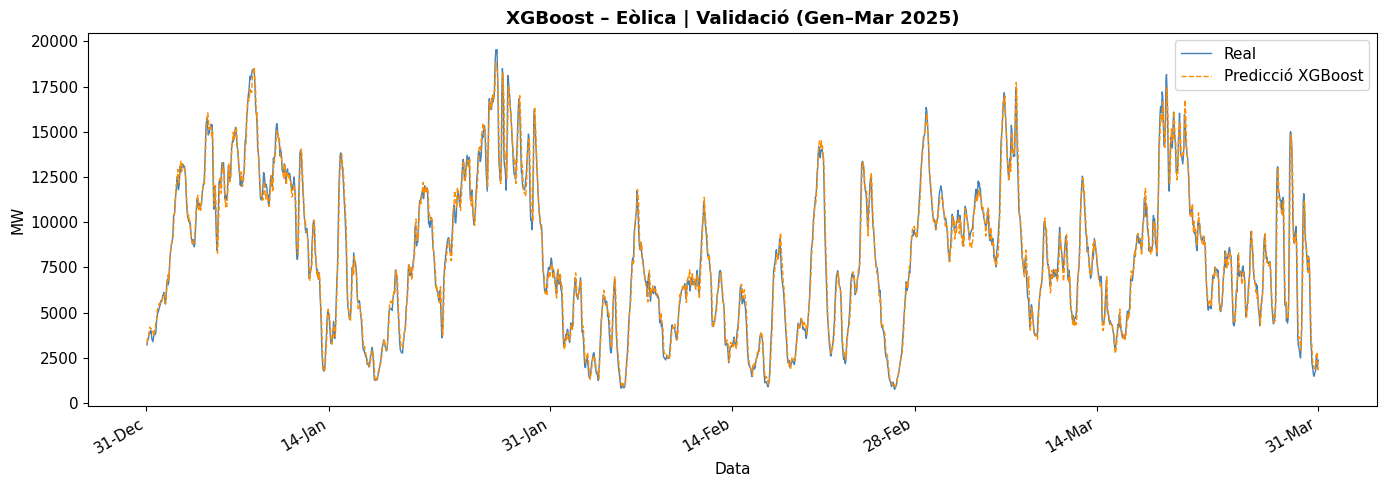

In [24]:
y_pred_val_eolic = np.clip(xgb_eolic.predict(X_val_eolic), 0, None)
metriques_val_eolic = calcular_metriques(
    y_val_eolic.values, y_pred_val_eolic, 'EÒLICA – Validació'
)

plot_prediccions(
    dates  = val.index,
    y_true = y_val_eolic.values,
    y_pred = y_pred_val_eolic,
    titol  = 'XGBoost – Eòlica | Validació (Gen–Mar 2025)'
)

### 7.4 Predicció i avaluació – Test (amb apagada)

--- EÒLICA – Test ---
  MAE : 377.9 MW
  RMSE: 519.1 MW
  MAPE: 9.65 %


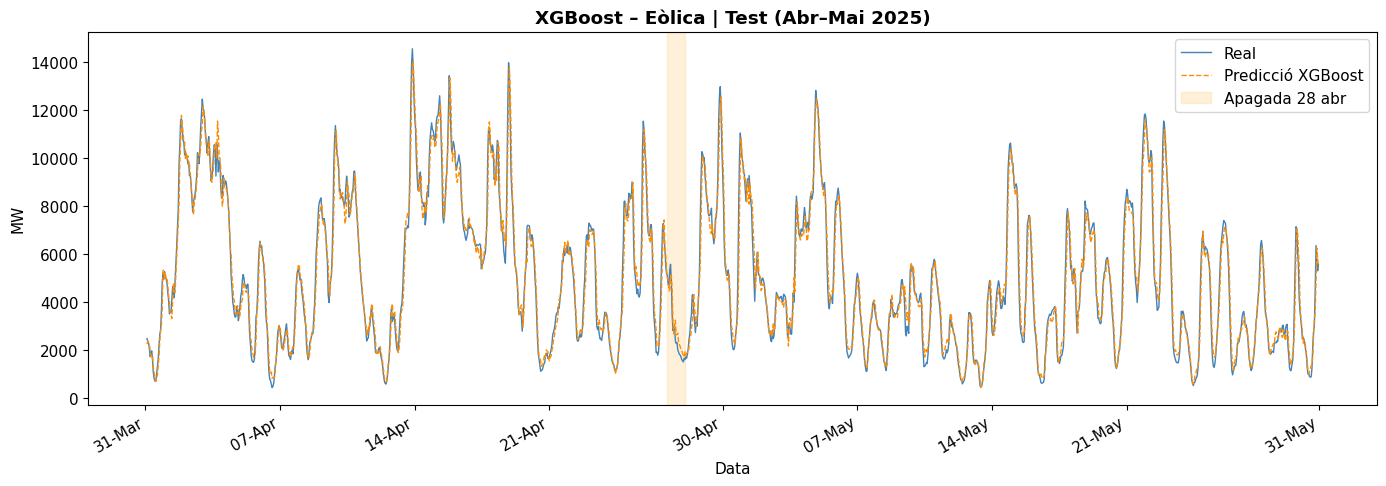

In [25]:
y_pred_test_eolic = np.clip(xgb_eolic.predict(X_test_eolic), 0, None)
metriques_test_eolic = calcular_metriques(
    y_test_eolic.values, y_pred_test_eolic, 'EÒLICA – Test'
)

plot_prediccions(
    dates           = test.index,
    y_true          = y_test_eolic.values,
    y_pred          = y_pred_test_eolic,
    titol           = 'XGBoost – Eòlica | Test (Abr–Mai 2025)',
    highlight_start = '2025-04-28 00:00',
    highlight_end   = '2025-04-28 23:00'
)

### 7.5 Importància de features – Eòlica

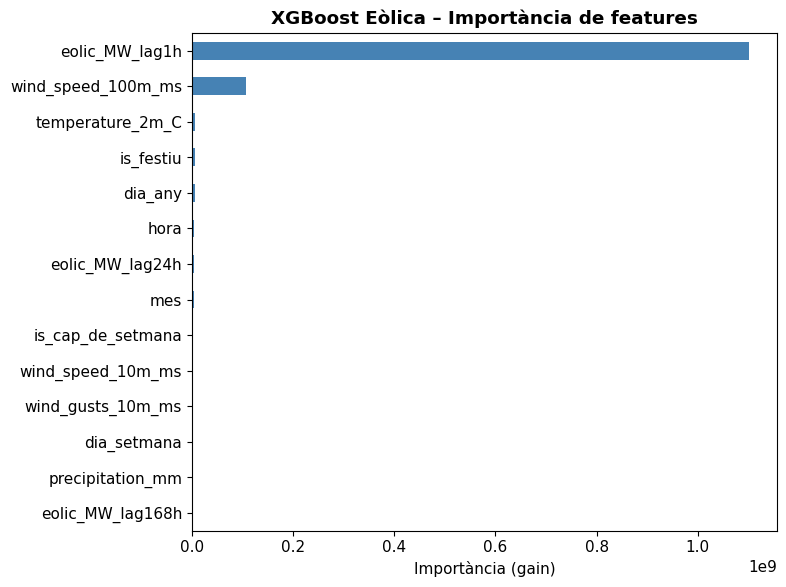

In [26]:
importances_eolic = pd.Series(
    xgb_eolic.get_booster().get_score(importance_type='gain'),
).reindex(FEATURES_EOLIC).fillna(0
).sort_values(ascending=True)
# 'gain': reducció mitjana de l'error aportada; més informatiu que 'weight'

fig, ax = plt.subplots(figsize=(8, 6))
importances_eolic.plot(kind='barh', ax=ax, color='steelblue')
ax.set_title('XGBoost Eòlica – Importància de features', fontweight='bold')
ax.set_xlabel('Importància (gain)')
plt.tight_layout()
plt.savefig('xgboost_eolic_feature_importance.pdf', bbox_inches='tight')
plt.show()

### 7.6 Anàlisi d'anomalies – Apagada 28 d'abril

Llindar anomalia eòlica: 1,090 MW
Hores anomàlies total: 73


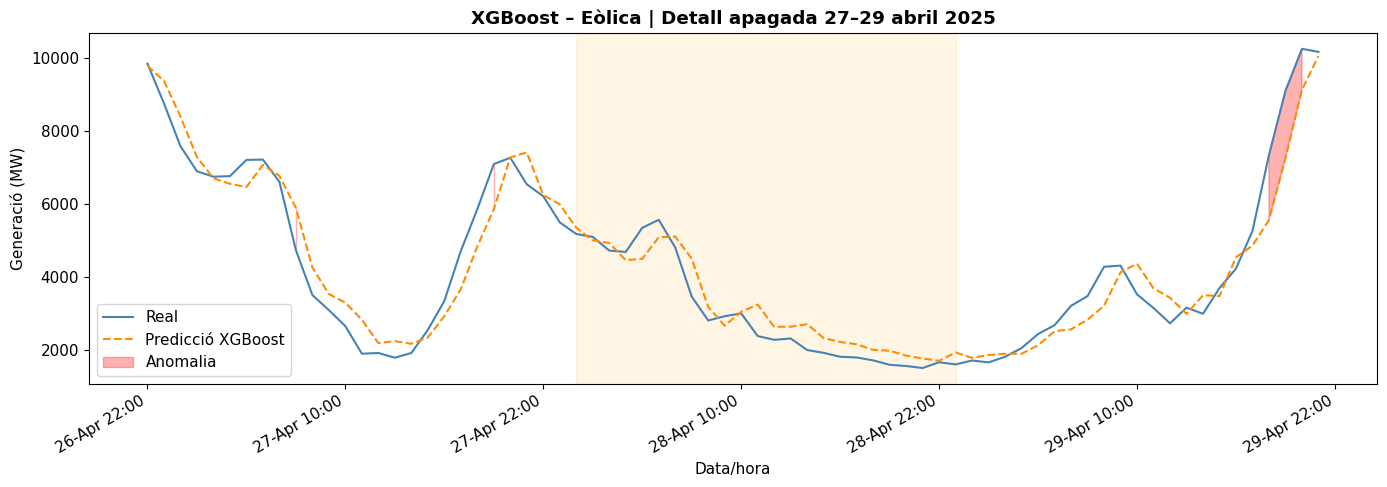

In [27]:
residus_eolic = pd.DataFrame({
    'ds':      test.index,
    'y_real':  y_test_eolic.values,
    'y_pred':  y_pred_test_eolic,
    'residu':  y_test_eolic.values - y_pred_test_eolic,
})

llindar_eolic = residus_eolic['residu'].abs().mean() + \
                2 * residus_eolic['residu'].abs().std()
residus_eolic['anomalia'] = residus_eolic['residu'].abs() > llindar_eolic

print(f'Llindar anomalia eòlica: {llindar_eolic:,.0f} MW')
print(f'Hores anomàlies total: {residus_eolic["anomalia"].sum()}')

mask_e = (residus_eolic['ds'] >= '2025-04-27') & \
         (residus_eolic['ds'] <= '2025-04-29 23:00')
sub_e = residus_eolic[mask_e]

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(sub_e['ds'], sub_e['y_real'], label='Real', color='steelblue', linewidth=1.5)
ax.plot(sub_e['ds'], sub_e['y_pred'], label='Predicció XGBoost', color='darkorange',
        linewidth=1.5, linestyle='--')
ax.fill_between(sub_e['ds'], sub_e['y_real'], sub_e['y_pred'],
                where=sub_e['anomalia'], alpha=0.3, color='red', label='Anomalia')
ax.axvspan(pd.Timestamp('2025-04-28 00:00'), pd.Timestamp('2025-04-28 23:00'),
           alpha=0.1, color='orange')
ax.set_title('XGBoost – Eòlica | Detall apagada 27–29 abril 2025', fontweight='bold')
ax.set_ylabel('Generació (MW)')
ax.set_xlabel('Data/hora')
ax.legend()
ax.xaxis.set_major_formatter(mdates.DateFormatter('%d-%b %H:%M'))
fig.autofmt_xdate()
plt.tight_layout()
plt.savefig('xgboost_eolic_detall_apagada.pdf', bbox_inches='tight')
plt.show()

---
## 9. Resum de mètriques

## 8. Baseline naïf (persistència)

El baseline de persistència prediu que el valor de la hora  és igual
al valor de la hora . És el model trivial mínim: si XGBoost no el supera,
no aporta valor real.

In [29]:
# Baseline naïf: y_pred(t) = y_real(t-1)
# Usem el lag1h que ja tenim al dataset (és exactament y(t-1))

# --- Solar ---
y_naive_val_solar  = val["solar_MW_lag1h"].values
y_naive_test_solar = test["solar_MW_lag1h"].values

print("=== BASELINE NAÏF (persistència) ===")
naive_val_solar  = calcular_metriques(y_val_solar.values,  y_naive_val_solar,  "SOLAR Naïf – Validació")
naive_test_solar = calcular_metriques(y_test_solar.values, y_naive_test_solar, "SOLAR Naïf – Test")

# --- Eòlica ---
y_naive_val_eolic  = val["eolic_MW_lag1h"].values
y_naive_test_eolic = test["eolic_MW_lag1h"].values

naive_val_eolic  = calcular_metriques(y_val_eolic.values,  y_naive_val_eolic,  "EÒLICA Naïf – Validació")
naive_test_eolic = calcular_metriques(y_test_eolic.values, y_naive_test_eolic, "EÒLICA Naïf – Test")


=== BASELINE NAÏF (persistència) ===
--- SOLAR Naïf – Validació ---
  MAE : 1,071.0 MW
  RMSE: 2,025.3 MW
  MAPE: 68.57 %
--- SOLAR Naïf – Test ---
  MAE : 1,297.3 MW
  RMSE: 2,332.0 MW
  MAPE: 46.57 %
--- EÒLICA Naïf – Validació ---
  MAE : 405.9 MW
  RMSE: 576.1 MW
  MAPE: 5.98 %
--- EÒLICA Naïf – Test ---
  MAE : 443.2 MW
  RMSE: 622.1 MW
  MAPE: 10.74 %


In [30]:
resum = pd.DataFrame({
    'Model / Conjunt': [
        'XGBoost Solar – Validació',
        'XGBoost Solar – Test',
        'XGBoost Eòlica – Validació',
        'XGBoost Eòlica – Test',
    ],
    'MAE (MW)':  [
        round(metriques_val_solar['MAE'],  1),
        round(metriques_test_solar['MAE'], 1),
        round(metriques_val_eolic['MAE'],  1),
        round(metriques_test_eolic['MAE'], 1),
    ],
    'RMSE (MW)': [
        round(metriques_val_solar['RMSE'],  1),
        round(metriques_test_solar['RMSE'], 1),
        round(metriques_val_eolic['RMSE'],  1),
        round(metriques_test_eolic['RMSE'], 1),
    ],
    'MAPE (%)':  [
        round(metriques_val_solar['MAPE'],  2),
        round(metriques_test_solar['MAPE'], 2),
        round(metriques_val_eolic['MAPE'],  2),
        round(metriques_test_eolic['MAPE'], 2),
    ],
})

print('\n=== RESUM MÈTRIQUES XGBOOST ===')
print(resum.to_string(index=False))

resum.to_csv('metriques_xgboost.csv', index=False)
print('\nDades desades a metriques_xgboost.csv')


=== RESUM MÈTRIQUES XGBOOST ===
           Model / Conjunt  MAE (MW)  RMSE (MW)  MAPE (%)
 XGBoost Solar – Validació     311.0      587.7     28.28
      XGBoost Solar – Test     414.6      729.5     20.04
XGBoost Eòlica – Validació     387.1      530.0      5.95
     XGBoost Eòlica – Test     377.9      519.1      9.65

Dades desades a metriques_xgboost.csv


---
## 10. Desar models

In [31]:
xgb_solar.save_model('xgboost_solar.json')
xgb_eolic.save_model('xgboost_eolic.json')
print('Models desats com xgboost_solar.json i xgboost_eolic.json')

Models desats com xgboost_solar.json i xgboost_eolic.json
